# Modernized Real Estate Modeling Workflow

## 1. Modernization Objective

This notebook is a **new companion** to the archived capstone, not a rewrite of it. It revisits the prediction of `hc_mortgage_mean` with leakage-safe preprocessing, training-only model selection, and an untouched final holdout. The original workflow remains in `real_estate_capstone.ipynb` for historical comparison.

The target represents mean monthly mortgage and owner costs for each geographic observation, so a regression task remains appropriate. Results describe this archived dataset only; they are not causal or production claims.

**Execution status:** This notebook was executed successfully in the validated environment; its displayed results and CSV reports were produced by that run rather than entered manually.

## 2. Imports and Configuration

`random_state=42` is used for repeatable folds and models. The reusable code lives in `src/modeling.py`; this notebook remains the narrative orchestration layer.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.modeling import (
    CATEGORICAL_FEATURES, MODEL_FEATURES, NUMERIC_FEATURES, TARGET,
    audit_split_overlap, holdout_overlap_indicators,
    build_pipeline, candidate_models, compare_models, load_datasets,
    prepare_supervised_data, regression_metrics, state_diagnostics,
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

## 3. Data Loading

The repository-provided training split is used for cross-validation and fitting. Because the test file also contains the target, it is reserved as the final holdout and is not consulted during feature selection or model selection.

In [2]:
train_raw, test_raw = load_datasets(ROOT / "data")
print("Train shape:", train_raw.shape)
print("Test shape:", test_raw.shape)

Train shape: (27321, 80)
Test shape: (11709, 80)


## 4. Dataset Validation

The following audit verifies shapes, columns, target availability, missing targets, exact duplicate rows, data types, and the apparent numeric/categorical split rather than assuming them. Exact duplicates are removed separately within each split after missing targets are removed; this avoids repeatedly scoring identical observations while preserving the test boundary.

In [3]:
def dataset_audit(name, frame):
    return pd.Series({
        "dataset": name,
        "rows": len(frame),
        "columns": frame.shape[1],
        "target_available": TARGET in frame.columns,
        "missing_targets": frame[TARGET].isna().sum() if TARGET in frame else np.nan,
        "exact_duplicates": frame.duplicated().sum(),
        "numeric_columns": frame.select_dtypes(include="number").shape[1],
        "non_numeric_columns": frame.select_dtypes(exclude="number").shape[1],
    })

audit = pd.DataFrame([dataset_audit("train", train_raw), dataset_audit("test", test_raw)])
display(audit)
display(pd.DataFrame({"train_dtype": train_raw.dtypes.astype(str),
                      "test_dtype": test_raw.dtypes.astype(str)}))
print("Columns identical:", train_raw.columns.equals(test_raw.columns))

,dataset,rows,columns,target_available,missing_targets,exact_duplicates,numeric_columns,non_numeric_columns
0,train,27321,80,True,573,160,74,6
1,test,11709,80,True,268,32,74,6


,train_dtype,test_dtype
UID,int64,int64
BLOCKID,float64,float64
SUMLEVEL,int64,int64
COUNTYID,int64,int64
STATEID,int64,int64
...,...,...
pct_own,float64,float64
married,float64,float64
married_snp,float64,float64
separated,float64,float64


Columns identical: True


## 4a. Train/Holdout Overlap Audit

A final holdout should ideally contain independent observations. If the same UID or an identical modeling-feature vector appears in both splits, reported test performance may be optimistic. This is a **potential holdout-independence concern**, not automatically proof of data leakage.

The audit hashes only the selected predictors after deterministic `age_median` engineering; it does not use `hc_mortgage_mean`, alter either split, or influence model selection. It reports unique UIDs shared by both original files and the number of holdout rows whose complete modeling-feature vector matches at least one training row. Any detected overlap is retained and documented rather than silently removed.

A direct integrity check of the tracked CSV files found **123 overlapping UID values** and **177 holdout observations with a modeling-feature vector also present in training**. These are overlap counts, not model-performance results. The executable cell below reproduces the audit when the required packages are available.

In [4]:
split_overlap = audit_split_overlap(train_raw, test_raw)
display(pd.Series(split_overlap, name="train_vs_holdout"))

overlapping_uid_values                  123
holdout_rows_matching_train_features    177
Name: train_vs_holdout, dtype: int64

## 5. Target Definition

`hc_mortgage_mean` is present in both files and is numeric. Rows without a target cannot teach or evaluate a supervised model, so they are removed—not imputed. The audit below records the actual counts. Test targets remain unused until the final pipeline has been chosen from training cross-validation.

In [5]:
X_train, y_train, train_audit = prepare_supervised_data(train_raw)
X_test, y_test, test_audit = prepare_supervised_data(test_raw)
display(pd.DataFrame([train_audit, test_audit], index=["train", "test"]))

,input_rows,missing_target_rows_removed,duplicate_rows_removed,modeling_rows
train,27321,573,29,26719
test,11709,268,9,11432


## 6. Feature Engineering

The one derived predictor is `age_median`, defined exactly as the arithmetic mean of `male_age_median` and `female_age_median`. It uses only values from the same observation and never the target. Missing inputs produce a missing derived value for the training-fitted imputer.

`pop_density` and `bad_debt` are not automatically carried over: land-area unit/zero handling and the incremental predictive meaning of a combined debt field require further domain validation.

In [6]:
display(X_train[MODEL_FEATURES].head())

,pop,family_mean,second_mortgage,home_equity,debt,hs_degree,age_median,pct_own,married,separated,divorced,STATEID,type
0,5230,67994.14790,0.02077,0.08919,0.52963,0.89288,44.666665,0.79046,0.57851,0.01240,0.08770,36,City
1,2633,50670.10337,0.02222,0.04274,0.60855,0.90487,34.791665,0.52483,0.34886,0.01426,0.09030,18,City
2,6881,95262.51431,0.00000,0.09512,0.73484,0.94288,41.833330,0.85331,0.64745,0.01607,0.10657,18,City
3,2700,56401.68133,0.01086,0.01086,0.52714,0.91500,49.750000,0.65037,0.47257,0.02021,0.10106,72,Urban
4,5637,54053.42396,0.05426,0.05426,0.51938,1.00000,22.000000,0.13046,0.12356,0.00000,0.03109,20,City


## 7. Feature Selection and Feature-Type Review

The compact predictor set retains population, family income, housing/debt proportions, education, ownership, marital indicators, and derived age. `type` and `STATEID` are categorical.

- **`STATEID`** is retained as a categorical label to represent broad location differences and support unseen-category-safe encoding.
- **`COUNTYID`** is excluded: it is an identifier whose magnitude is not a continuous quantity and whose meaning is tied to state; naive inclusion could create misleading ordering.
- **`zip_code`** is excluded: it is a high-cardinality postal identifier, not a continuous measurement.

These choices are made before viewing holdout outcomes. They reduce arbitrary numeric relationships and keep the portfolio model explainable.

In [7]:
print("Numeric features:", NUMERIC_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)

Numeric features: ['pop', 'family_mean', 'second_mortgage', 'home_equity', 'debt', 'hs_degree', 'age_median', 'pct_own', 'married', 'separated', 'divorced']
Categorical features: ['STATEID', 'type']


## 8. Preprocessing Pipeline

**Interview notes:**

- **Training vs test data:** training data is used to learn and select; test data estimates performance once, after those decisions.
- **Data leakage:** information from validation/test rows must not influence fitted preprocessing or the model.
- **Fit vs transform:** `fit` learns medians, scale parameters, and categories; `transform` applies those learned values without relearning them.
- **Pipeline:** chains preprocessing and estimation so cross-validation refits the entire learning process inside each training fold.
- **ColumnTransformer:** applies median imputation and scaling to numeric columns, while categorical columns receive most-frequent imputation and one-hot encoding.
- **Imputation:** fills missing predictors using values learned only from training data. The target is never imputed.

`OneHotEncoder(handle_unknown="ignore")` permits a category found only in the holdout to be represented without a crash. The final test call uses the already fitted pipeline; there is no test-set `fit_transform()`.

In [8]:
preview_pipeline = build_pipeline(candidate_models()["Ridge"])
preview_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, defau

## 9. Baseline Model

`DummyRegressor` predicts the training mean. A model should beat this trivial reference before its complexity is considered useful.

## 10. Model Comparison

The intentionally small model set covers a baseline, unregularized linear model, regularized linear model, and nonlinear tree ensemble. No test values participate in this comparison.

In [9]:
list(candidate_models(RANDOM_STATE))

['DummyRegressor', 'LinearRegression', 'Ridge', 'RandomForestRegressor']

## 11. Cross-Validation

Five shuffled, reproducible folds are used on training data only. Because preprocessing is inside each pipeline, imputers, scaling, and categories are learned anew from each fold's training portion. We report mean and standard deviation for R², RMSE, and MAE. RMSE is calculated as the square root of fold MSE rather than through a version-sensitive shortcut.

In [10]:
comparison = compare_models(X_train, y_train, RANDOM_STATE)
display(comparison.round(3))
reports_dir = ROOT / "reports"
reports_dir.mkdir(exist_ok=True)
comparison.to_csv(reports_dir / "model_comparison.csv", index=False)

,model,r2_mean,r2_std,rmse_mean,rmse_std,mae_mean,mae_std
0,RandomForestRegressor,0.834,0.007,253.666,6.452,178.043,2.446
1,Ridge,0.817,0.008,266.083,5.747,187.482,2.355
2,LinearRegression,0.817,0.008,266.085,5.750,187.479,2.343
3,DummyRegressor,-0.000,0.000,622.449,9.198,498.431,7.517


## 12. Final Holdout Evaluation

The lowest mean cross-validation RMSE selects the final candidate; this rule is defined without examining test performance. That pipeline is fitted on all eligible training observations, then predicts the untouched holdout once. Metrics are regression metrics—not “accuracy.”

In [11]:
selected_name = comparison.iloc[0]["model"]
final_pipeline = build_pipeline(candidate_models(RANDOM_STATE)[selected_name])
final_pipeline.fit(X_train, y_train)
test_predictions = final_pipeline.predict(X_test)
test_metrics = regression_metrics(y_test, test_predictions)
print("Selected from training CV:", selected_name)
display(pd.Series(test_metrics, name="holdout"))

Selected from training CV: RandomForestRegressor


r2        0.841877
rmse    252.270119
mae     177.562609
Name: holdout, dtype: float64

## 12a. Non-Overlap Holdout Sensitivity Analysis

The predefined full holdout remains the main evaluation. This second evaluation is only a robustness check: it applies the **same existing predictions from the already-fitted Random Forest pipeline** after excluding eligible holdout rows that either share a UID with eligible training data or exactly match an approved training predictor vector. The target does not determine the mask, training observations are not removed, and the model is not refitted.

Overlapping rows did not participate in model selection; selection was already completed using training cross-validation. Similar metrics would suggest that exact overlap is not primarily driving reported performance, while materially different metrics would indicate that holdout independence meaningfully affects the estimate. In either case, this filtered subset is not a new independent external validation dataset.

In [12]:
eligible_train_raw = train_raw.loc[X_train.index]
eligible_holdout_raw = test_raw.loc[X_test.index]
overlap_indicators = holdout_overlap_indicators(
    eligible_train_raw, eligible_holdout_raw
)
non_overlap_mask = ~overlap_indicators["any_overlap"]

sensitivity_counts = pd.Series({
    "original_eligible_holdout_rows": len(X_test),
    "shared_uid_rows": int(overlap_indicators["shared_uid"].sum()),
    "matching_feature_rows": int(overlap_indicators["matching_features"].sum()),
    "overlap_union_rows": int(overlap_indicators["any_overlap"].sum()),
    "remaining_non_overlap_rows": int(non_overlap_mask.sum()),
}, name="rows")
display(sensitivity_counts)

sensitivity_metrics = regression_metrics(
    y_test.loc[non_overlap_mask],
    test_predictions[non_overlap_mask.to_numpy()],
)
holdout_sensitivity = pd.DataFrame([
    {"evaluation": "Full holdout", "rows": len(X_test), **test_metrics},
    {"evaluation": "Non-overlap sensitivity subset",
     "rows": int(non_overlap_mask.sum()), **sensitivity_metrics},
])
display(holdout_sensitivity)

absolute_metric_differences = (
    holdout_sensitivity.loc[1, ["r2", "rmse", "mae"]]
    - holdout_sensitivity.loc[0, ["r2", "rmse", "mae"]]
).abs()
display(absolute_metric_differences.rename("absolute difference"))

holdout_sensitivity.to_csv(
    reports_dir / "holdout_sensitivity.csv", index=False
)

original_eligible_holdout_rows    11432
shared_uid_rows                      31
matching_feature_rows                31
overlap_union_rows                   31
remaining_non_overlap_rows        11401
Name: rows, dtype: int64

,evaluation,rows,r2,rmse,mae
0,Full holdout,11432,0.841877,252.270119,177.562609
1,Non-overlap sensitivity subset,11401,0.842473,251.476988,177.144459


r2      0.000596
rmse    0.793131
mae     0.418150
Name: absolute difference, dtype: float64

## 13. Residual / Error Analysis

Predicted-vs-actual checks broad calibration, residuals-vs-predicted checks whether error spread/patterns change over predictions, and the residual histogram shows error shape. These plots can flag issues but do **not** prove normality, homoscedasticity, causation, or business significance.

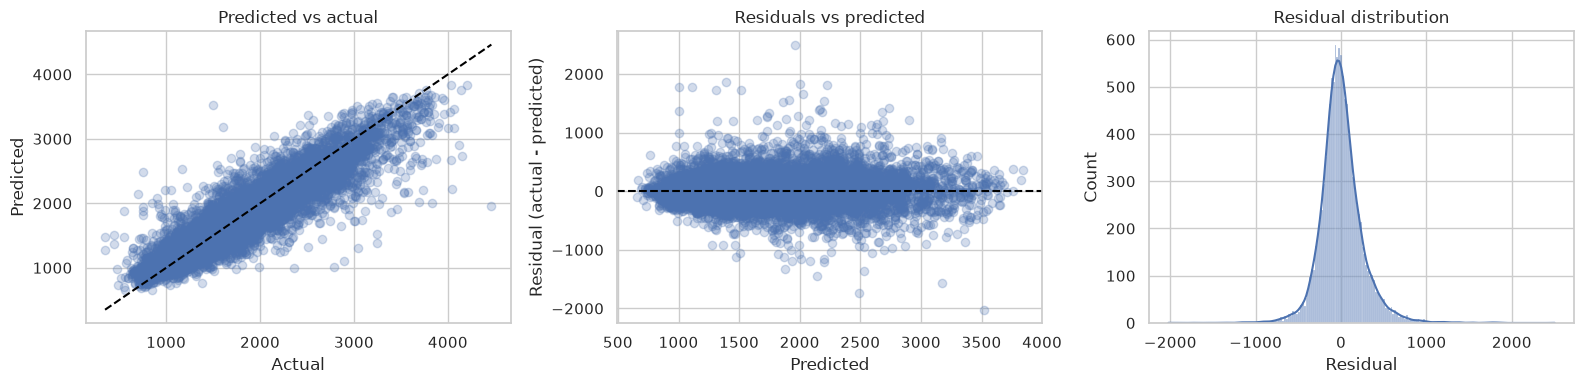

In [13]:
residuals = y_test.to_numpy() - test_predictions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].scatter(y_test, test_predictions, alpha=.25)
limits = [min(y_test.min(), test_predictions.min()), max(y_test.max(), test_predictions.max())]
axes[0].plot(limits, limits, "--", color="black")
axes[0].set(xlabel="Actual", ylabel="Predicted", title="Predicted vs actual")
axes[1].scatter(test_predictions, residuals, alpha=.25)
axes[1].axhline(0, linestyle="--", color="black")
axes[1].set(xlabel="Predicted", ylabel="Residual (actual - predicted)", title="Residuals vs predicted")
sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set(title="Residual distribution", xlabel="Residual")
plt.tight_layout();

In [14]:
errors = pd.DataFrame({
    "source_index": y_test.index,
    "actual": y_test.to_numpy(),
    "predicted": test_predictions,
    "residual": residuals,
    "absolute_error": np.abs(residuals),
}).nlargest(10, "absolute_error")
display(errors)

,source_index,actual,predicted,residual,absolute_error
9611,9840,4462.34229,1960.911567,2501.430723,2501.430723
3857,3948,1498.36725,3520.718178,-2022.350928,2022.350928
9366,9588,3249.50000,1388.121462,1861.378538,1861.378538
9770,10006,3830.43732,2005.426620,1825.010700,1825.010700
1140,1170,4038.22035,2229.137678,1809.082672,1809.082672
262,271,2888.64210,1111.136389,1777.505711,1777.505711
2573,2636,2785.21284,1007.958559,1777.254281,1777.254281
1849,1898,749.50000,2488.113078,-1738.613078,1738.613078
6527,6682,3041.36707,1307.870731,1733.496339,1733.496339
2685,2749,3249.50000,1519.191048,1730.308952,1730.308952


## 14. State-Level Diagnostics

These are subgroup diagnostics from the **global** final model, not separately trained state models. They group by `STATEID` (not the historical workflow's mistaken `COUNTYID`). A 30-observation minimum avoids presenting very small groups as reliable; R² is calculated only for groups that pass that documented threshold.

In [15]:
state_metrics = state_diagnostics(
    X_test["STATEID"], y_test, test_predictions, minimum_observations=30
)
display(state_metrics)
state_metrics.to_csv(reports_dir / "state_metrics.csv", index=False)

,STATEID,observations,r2,rmse,mae
0,20,132,0.880645,143.099606,112.816255
1,46,38,0.681598,147.684261,122.408576
2,16,47,0.615034,153.407525,114.512836
3,28,105,0.694662,153.993472,122.140985
4,19,127,0.596691,155.479033,121.746872
5,47,253,0.787476,159.482135,113.703646
6,55,192,0.791135,164.707300,122.033724
7,54,96,0.602188,167.160314,135.015529
8,5,92,0.606175,167.592962,131.692190
9,23,60,0.782129,170.940931,136.057506


### Predictive interpretability

The view below works for the selected Ridge/linear or random-forest candidate and uses transformed feature names. Magnitude can be affected by preprocessing, correlated predictors, and model form. **Predictive importance or coefficient size does not establish causation.**

In [16]:
feature_names = final_pipeline.named_steps["preprocessor"].get_feature_names_out()
model = final_pipeline.named_steps["model"]
if hasattr(model, "feature_importances_"):
    values, value_name = model.feature_importances_, "importance"
elif hasattr(model, "coef_"):
    values, value_name = np.ravel(model.coef_), "coefficient"
else:
    values, value_name = None, None
if values is not None:
    interpretation = (pd.DataFrame({"feature": feature_names, value_name: values})
                      .assign(magnitude=lambda d: d[value_name].abs())
                      .nlargest(15, "magnitude"))
    display(interpretation.drop(columns="magnitude"))
else:
    print("The selected baseline has no feature-level importance values.")

,feature,importance
1,numeric__family_mean,0.639201
7,numeric__pct_own,0.065523
59,categorical__STATEID_6,0.059663
38,categorical__STATEID_36,0.041984
5,numeric__hs_degree,0.027071
36,categorical__STATEID_34,0.020566
4,numeric__debt,0.020221
3,numeric__home_equity,0.019296
10,numeric__divorced,0.019281
6,numeric__age_median,0.016748


## 15. Comparison With Historical Result

The archived notebook stored R² ≈ 0.7348 and RMSE ≈ 323.10. The table populates the modern row only from the executed holdout evaluation above. A direct better/worse conclusion would be misleading because duplicate/target handling, features, categorical treatment, preprocessing, selection, and validation methodology differ.

In [17]:
historical_comparison = pd.DataFrame([
    {"Workflow": "Historical notebook", "R2": 0.7348, "RMSE": 323.10,
     "Notes": "Historical methodology; known preprocessing limitations"},
    {"Workflow": "Modernized workflow", "R2": test_metrics["r2"],
     "RMSE": test_metrics["rmse"],
     "Notes": "Pipeline preprocessing, training CV, untouched holdout"},
])
display(historical_comparison)

,Workflow,R2,RMSE,Notes
0,Historical notebook,0.734800,323.100000,Historical methodology; known preprocessing li...
1,Modernized workflow,0.841877,252.270119,"Pipeline preprocessing, training CV, untouched..."


## 16. Limitations

- The archived dataset's age, collection process, definitions, sampling, and external source are not fully documented here.
- Exact duplicates are removed, but near-duplicates or related geographies could still cross folds/splits.
- The overlap audit is a diagnostic: any shared UID or identical predictor row may weaken holdout independence, but is not removed or used to tune the workflow.
- Random K-fold validation does not model geographic or temporal distribution shift.
- The feature strategy is intentionally modest and has limited business/domain validation.
- State diagnostics may reveal error differences but do not explain their causes or establish fairness.
- No production monitoring, deployment, uncertainty intervals, or external validation is included.
- Unpinned dependencies mean future runtime behavior is not guaranteed.

## 17. Conclusions

This workflow makes the modeling process auditable: missing targets are removed explicitly, identifiers receive semantic review, preprocessing is fit only within training, a trivial baseline anchors comparison, candidate selection uses cross-validation, and the holdout is evaluated only after selection. Interpret conclusions from the executed cells rather than from the historical metrics alone.

## 18. Next Improvements

1. Confirm the original data dictionary, units, collection period, and intended prediction use case.
2. Evaluate group-aware or geography-aware validation after defining geographic dependence.
3. Study sensitivity to duplicate policy, feature choices, and the state minimum-count threshold.
4. Add prediction intervals and stability checks across repeated folds.
5. Pin a tested environment and automate notebook execution in continuous integration.
6. Review subgroup errors with domain experts before any operational use.

## Validated Runtime

The versions below are queried from the environment rather than inferred from `requirements.txt`. They document this execution, not every transitive dependency.

In [18]:
import platform
import sklearn

pd.Series({
    "execution_date": "2026-09-25",
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
}, name="validated runtime")

execution_date    2026-09-25
python               3.12.13
numpy                  2.5.3
pandas                 3.0.6
scikit_learn           1.9.1
Name: validated runtime, dtype: str